### Exploratory Data Analysis

Loading of the dataset to see what concepts are most common. 

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        106 non-null    int64 
 1   source    106 non-null    object
 2   query     106 non-null    object
 3   concepts  106 non-null    object
 4   filters   106 non-null    object
dtypes: int64(1), object(4)
memory usage: 4.3+ KB
None


,id,source,query,concepts,filters
0,1,lumin_test_dataset_v3,Show me high resolution images from the Mars R...,High Resolution Imaging | Mars Rovers,"{""gather.common.instrument"": [""HIRISE"", ""ISS"",..."
1,2,lumin_test_dataset_v3,Find spectroscopy data for the Saturn System,Spectroscopy (Composition) | Saturn System,"{""gather.common.instrument"": [""VIMS"", ""NIMS"", ..."
2,3,lumin_test_dataset_v3,Retrieve raw data from Perseverance,Raw Data | Mars Rovers,"{""gather.common.product_type"": [""EDR"", ""RAW_IM..."
3,4,lumin_test_dataset_v3,Search for radar data from Mars,Radar Systems | Mars System,"{""gather.common.instrument"": [""RADAR"", ""MGN-RA..."
4,5,lumin_test_dataset_v3,Show me hazard camera images,Hazard & Navigation Cameras,"{""gather.common.instrument"": [""NAVCAM"", ""NAVCA..."


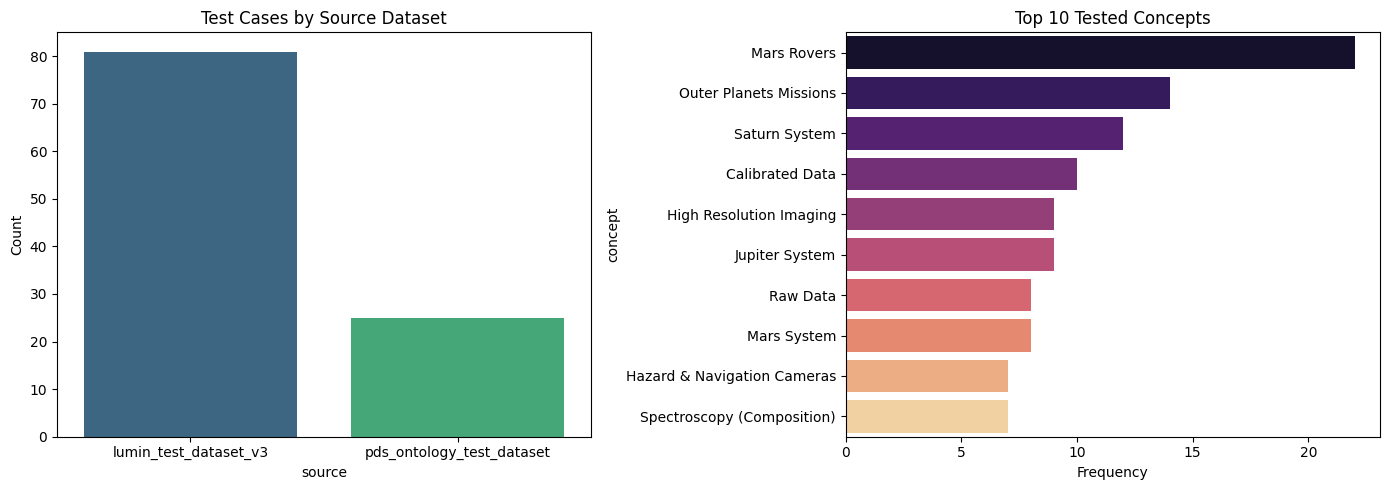


Filter Complexity (Keys per Query):
filter_key_count
1    71
2    30
3     5
Name: count, dtype: int64


In [10]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Load the normalized dataset from the data/ directiory 

df_path = Path('../data/normalized_pds_test_dataset.csv')
df = pd.read_csv(df_path)

print("Dataset Overview:")
print(df.info())
display(df.head())

# --- EDA Visualizations ---
plt.figure(figsize=(14, 5))

# 1. Distribution of Sources
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='source', hue='source', palette='viridis', legend=False)
plt.title('Test Cases by Source Dataset')
plt.ylabel('Count')

# 2. Top 10 Concepts Tested
plt.subplot(1, 2, 2)
# Some concepts are piped (e.g., "High Resolution Imaging | Mars Rovers"), so split on the literal separator
all_concepts = df['concepts'].str.split(' | ', regex=False).explode().str.strip()
concept_counts = all_concepts.value_counts().head(10)
concept_df = concept_counts.rename_axis('concept').reset_index(name='count')
sns.barplot(data=concept_df, y='concept', x='count', hue='concept', palette='magma', legend=False)
plt.title('Top 10 Tested Concepts')
plt.xlabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Analyze Filter Complexity (Number of keys per expected filter)
df['filter_key_count'] = df['filters'].apply(lambda x: len(json.loads(x).keys()))
print("\nFilter Complexity (Keys per Query):")
print(df['filter_key_count'].value_counts())

###  Ontology Loading & Prompt Formatting
This block dynamically loads the ontology.json file and formats it into a tight, context-efficient string for the LLMs.

In [12]:
import os

# Load Ontology
with open('../data/ontology.json', 'r') as f:
    raw_ontology = json.load(f)

def format_ontology_for_prompt(ontology_dict):
    """Flattens and formats the nested PDS ontology into a clear string for the LLM."""
    lines = []
    for category, concepts in ontology_dict.items():
        if category == "__METADATA__": continue
        
        group_name = category.strip("_").replace("_", " ").title()
        lines.append(f"\n## {group_name}")
        
        for concept_name, details in concepts.items():
            desc = details.get("description", "")
            field = details.get("field", "")
            values = details.get("values", [])
            val_str = ", ".join(values[:5]) + ("..." if len(values) > 5 else "")
            
            lines.append(f"- Concept: '{concept_name}'")
            lines.append(f"  Field: {field}")
            lines.append(f"  Valid Values: [{val_str}]")
            if desc: lines.append(f"  Desc: {desc}")
    return "\n".join(lines)

ONTOLOGY_CONTEXT = format_ontology_for_prompt(raw_ontology)
print("Ontology Context Loaded. Length:", len(ONTOLOGY_CONTEXT), "characters")

Ontology Context Loaded. Length: 2979 characters


### The Benchmarking Experiment Pipeline
This is the core execution loop. It queries OpenRouter, strictly requests JSON output, and compares the model's generated fields and values against the ground truth in the CSV.

In [13]:
from openai import OpenAI
import time
import ast

# Initialize OpenRouter Client
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
)

# Models to test (adjust IDs based on current OpenRouter availability)
MODELS = {
    "Baseline_Large": "anthropic/claude-4.6-opus", 
    "Challenger_Small": "google/gemma-4-26b-a4b-it",
    "Nemotron_Super": "nvidia/nemotron-3-super-120b-a12b:free",
    "Llama_4_Maverick": "meta-llama/llama-4-maverick",
    "GPT_OSS_120B": "openai/gpt-oss-120b:free",
    "GPT_5_4": "openai/gpt-5.4",
    
}

# System Prompts
PROMPT_WITH_ONTOLOGY = f"""
You are an expert NASA PDS data archivist.
Map the user's natural language query to the correct PDS4 search filters.

AVAILABLE ONTOLOGY:
{ONTOLOGY_CONTEXT}

RULES:
1. Output ONLY a valid JSON object mapping the 'Field' to a list of its 'Valid Values' based on the user's intent.
2. Example output format: {{"gather.common.mission": ["Mars 2020"], "gather.common.instrument": ["NAVCAM"]}}
3. Do not include markdown blocks, explanations, or any text outside the JSON.
"""

PROMPT_NO_ONTOLOGY = """
You are an expert NASA PDS data archivist.
Map the user's natural language query to the correct PDS4 search filters.

RULES:
1. Output ONLY a valid JSON object mapping standard PDS metadata fields (e.g., gather.common.mission, gather.common.instrument, gather.common.target) to a list of target values.
2. Example output format: {{"gather.common.mission": ["Mars 2020"]}}
3. Do not include markdown blocks, explanations, or any text outside the JSON.
"""

def evaluate_model(df, model_id, use_ontology=True, sample_size=10):
    """Runs a subset of the dataset through the model and calculates accuracy."""
    system_prompt = PROMPT_WITH_ONTOLOGY if use_ontology else PROMPT_NO_ONTOLOGY
    results = []
    
    # Sample the dataframe for faster iteration during testing
    test_df = df.sample(sample_size, random_state=42)
    
    for idx, row in test_df.iterrows():
        expected_filters = json.loads(row['filters'])
        
        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": row['query']}
                ],
                temperature=0.0,
                # Force JSON output format if supported by the model on OpenRouter
                response_format={"type": "json_object"} 
            )
            
            raw_output = response.choices[0].message.content.strip()
            
            # Clean potential markdown formatting
            if raw_output.startswith("```json"):
                raw_output = raw_output[7:-3].strip()
            elif raw_output.startswith("```"):
                raw_output = raw_output[3:-3].strip()
                
            predicted_filters = json.loads(raw_output)
            
            # Basic evaluation logic: Check if predicted keys match expected keys
            expected_keys = set(expected_filters.keys())
            predicted_keys = set(predicted_filters.keys())
            
            # Calculate field mapping accuracy
            field_match = 1 if expected_keys.issubset(predicted_keys) else 0
            
            results.append({
                "id": row['id'],
                "query": row['query'],
                "expected": expected_filters,
                "predicted": predicted_filters,
                "field_match": field_match
            })
            
        except Exception as e:
            print(f"Error on ID {row['id']}: {e}")
            results.append({
                 "id": row['id'], "query": row['query'], 
                 "expected": expected_filters, "predicted": {}, "field_match": 0
            })
            
        # Respect API rate limits
        time.sleep(1.5)
        
    results_df = pd.DataFrame(results)
    accuracy = results_df['field_match'].mean() * 100
    print(f"Model: {model_id} | Ontology: {use_ontology} | Accuracy: {accuracy:.1f}%")
    
    return results_df

# --- Run the Experiment ---
# Note: Increase sample_size to len(df) for the full run
print("Starting Benchmark Suite...")
results_small_with_ont = evaluate_model(df, MODELS["Challenger_Small"], use_ontology=True, sample_size=15)
results_small_no_ont = evaluate_model(df, MODELS["Challenger_Small"], use_ontology=False, sample_size=15)
results_large_with_ont = evaluate_model(df, MODELS["Baseline_Large"], use_ontology=True, sample_size=15)
results_large_no_ont = evaluate_model(df, MODELS["Baseline_Large"], use_ontology=False, sample_size=15)

Starting Benchmark Suite...
Model: google/gemma-4-26b-a4b-it | Ontology: True | Accuracy: 93.3%
Model: google/gemma-4-26b-a4b-it | Ontology: False | Accuracy: 53.3%
Model: anthropic/claude-4.6-opus | Ontology: True | Accuracy: 100.0%
Model: anthropic/claude-4.6-opus | Ontology: False | Accuracy: 60.0%


### Analyzing the Results
Now, we visualize the performance gap. 

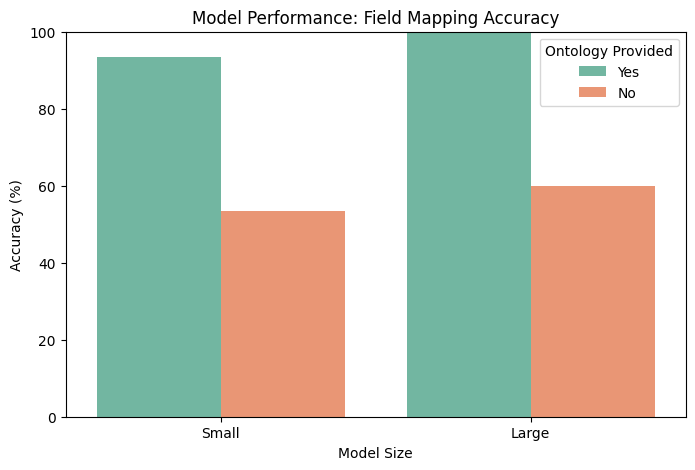

Failed cases for Small Model (With Ontology): 1


,query,expected,predicted
7,SHERLOC Raman spectroscopy data on Martian roc...,"{'gather.common.instrument': ['SHERLOC_ACI'], ...","{'gather.common.instrument': ['APXS'], 'gather..."


In [14]:
# Combine results for visualization
summary_data = [
    {"Model Size": "Small", "Ontology Used": "Yes", "Accuracy": results_small_with_ont['field_match'].mean() * 100},
    {"Model Size": "Small", "Ontology Used": "No",  "Accuracy": results_small_no_ont['field_match'].mean() * 100},
    {"Model Size": "Large", "Ontology Used": "Yes", "Accuracy": results_large_with_ont['field_match'].mean() * 100},
    {"Model Size": "Large", "Ontology Used": "No",  "Accuracy": results_large_no_ont['field_match'].mean() * 100},
]

summary_df = pd.DataFrame(summary_data)

plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x="Model Size", y="Accuracy", hue="Ontology Used", palette="Set2")
plt.title("Model Performance: Field Mapping Accuracy")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend(title='Ontology Provided')
plt.show()

# Print detailed failure cases for the small model with ontology
failures = results_small_with_ont[results_small_with_ont['field_match'] == 0]
print(f"Failed cases for Small Model (With Ontology): {len(failures)}")
display(failures[['query', 'expected', 'predicted']])